In [60]:
import nltk.corpus
from collections import Counter
from typing import List
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt

nltk.download('brown')
nltk.download('indian')

brown = nltk.corpus.brown
indian = nltk.corpus.indian
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package brown to
[nltk_data]     /Users/jadenvanrijswijk/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package indian to
[nltk_data]     /Users/jadenvanrijswijk/nltk_data...
[nltk_data]   Package indian is already up-to-date!


In [76]:
# Step 1
def common_words(words: List[str], n: int):
    words = [w.lower() for w in words if w.isalpha()] # Lower aplha
    words = [w for w in words if w not in stop_words] # No stopwords
    freq_words = Counter(words)
    commons = freq_words.most_common()
    return commons[:n]

commons_brown = common_words(brown.words(), 100)
commons_religion = common_words(brown.words(categories='religion'), 100)
commons_mystery = common_words(brown.words(categories='mystery'), 100)

print(commons_brown) # i
print(commons_religion, commons_mystery) # ii

[('one', 3292), ('would', 2714), ('said', 1961), ('new', 1635), ('could', 1601), ('time', 1598), ('two', 1412), ('may', 1402), ('first', 1361), ('like', 1292), ('man', 1207), ('even', 1170), ('made', 1125), ('also', 1069), ('many', 1030), ('must', 1013), ('af', 996), ('back', 966), ('years', 950), ('much', 937), ('way', 908), ('well', 897), ('people', 847), ('little', 831), ('state', 807), ('good', 806), ('make', 794), ('world', 787), ('still', 782), ('see', 772), ('men', 763), ('work', 762), ('long', 752), ('get', 749), ('life', 715), ('never', 697), ('day', 687), ('another', 684), ('know', 683), ('last', 676), ('us', 675), ('might', 672), ('great', 665), ('old', 661), ('year', 658), ('come', 630), ('since', 628), ('go', 626), ('came', 622), ('right', 613), ('used', 611), ('take', 610), ('three', 610), ('states', 603), ('house', 591), ('use', 591), ('without', 583), ('place', 570), ('american', 569), ('around', 562), ('however', 552), ('home', 547), ('small', 542), ('found', 536), ('t

In [74]:
# Step 2
def extract_insights(corpus, category=None, language=None):
    if category is None:
        words = corpus.words()
        sents = corpus.sents()
    elif language is not None:
        words = corpus.words(language + '.pos')
        sents = corpus.sents(language + '.pos')
    else:
        words = corpus.words(categories=category)
        sents = corpus.sents(categories=category)
        
    n_tokens = len(words) # i
    n_types = len(set(words)) # ii
    n_words = [w.lower() for w in words if w.isalpha() and w.lower()] # iii
    avg_words_sent = len(n_words) / len(sents) # iv
    avg_word_len = sum(len(w) for w in n_words) / len(n_words) # v
    lemmas = [lemmatizer.lemmatize(w) for w in n_words]
    n_lemmas = len(set(lemmas)) # vi
    print(f"Insights gathered:\n Number of tokens: {n_tokens}\n Number of types: {n_types}\n Average words per sentence: {avg_words_sent:.2f}\n Average word length: {avg_word_len:.2f}\n Number of lemmas: {n_lemmas}\n")

extract_insights(brown)
extract_insights(brown, category='religion')
extract_insights(brown, category='mystery')

Insights gathered:
 Number of tokens: 1161192
 Number of types: 56057
 Average words per sentence: 17.12
 Average word length: 4.68
 Number of lemmas: 34998

Insights gathered:
 Number of tokens: 39399
 Number of types: 6373
 Average words per sentence: 19.79
 Average word length: 4.70
 Number of lemmas: 5042

Insights gathered:
 Number of tokens: 57169
 Number of types: 6982
 Average words per sentence: 11.99
 Average word length: 4.22
 Number of lemmas: 5556



In [ ]:
# Step 3
tag_freqs = Counter([p[1] for p in brown.tagged_words()])
print(tag_freqs.most_common(10))

[('NN', 152470), ('IN', 120557), ('AT', 97959), ('JJ', 64028), ('.', 60638), (',', 58156), ('NNS', 55110), ('CC', 37718), ('RB', 36464), ('NP', 34476)]


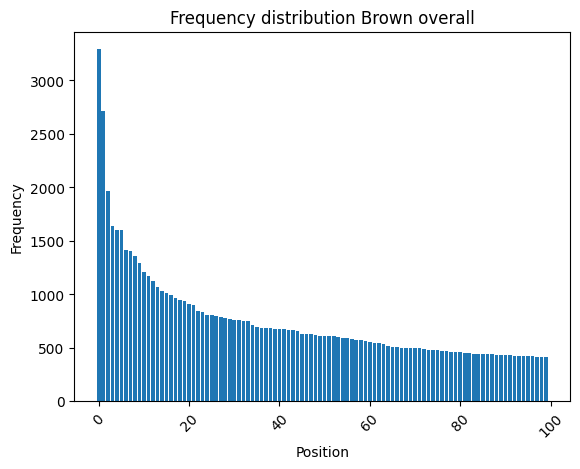

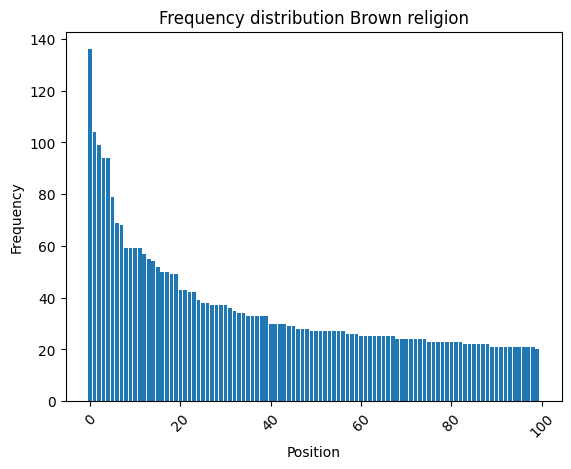

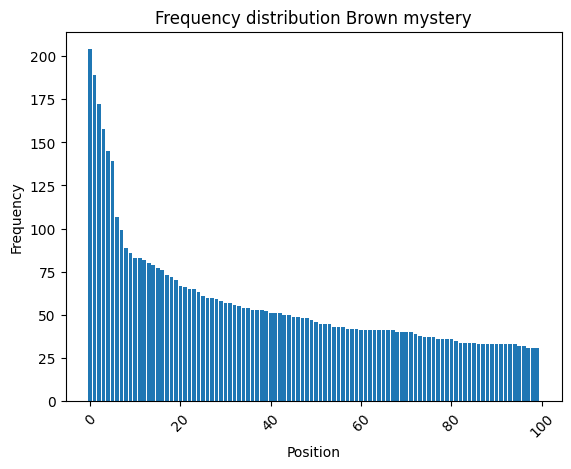

In [ ]:
# Step 4
def plot_frequency_distribution(commons, suffix=''):
    words, freqs = zip(*commons)
    indices = range(len(words))
    plt.bar(indices, freqs)
    plt.xlabel('Position')
    plt.ylabel('Frequency')
    plt.title(f'Frequency distribution {suffix}')
    plt.show()
    
plot_frequency_distribution(commons_brown, 'Brown')
plot_frequency_distribution(commons_religion, 'Brown religion')
plot_frequency_distribution(commons_mystery, 'Brown mystery')

[('पर', 131), ('और', 130), ('व', 116), ('ఈ', 112), ('হয়', 110), ('एक', 103), ('ఆ', 93), ('এই', 62), ('रन', 60), ('कर', 59)] [('पर', 131), ('और', 129), ('रन', 60), ('कर', 59), ('इस', 56), ('एक', 54), ('गई', 26), ('यह', 25), ('व', 16), ('गए', 15)] [('হয়', 110), ('এই', 62), ('ও', 57), ('আর', 40), ('এক', 36), ('নকল', 36), ('নয়', 31), ('আজ', 31), ('সময়', 24), ('এ', 20)]
Insights gathered:
 Number of tokens: 48754
 Number of types: 16143
 Average words per sentence: 0.76
 Average word length: 2.13
 Number of lemmas: 436

Insights gathered:
 Number of tokens: 48754
 Number of types: 16143
 Average words per sentence: 0.76
 Average word length: 2.13
 Number of lemmas: 436

Insights gathered:
 Number of tokens: 48754
 Number of types: 16143
 Average words per sentence: 0.76
 Average word length: 2.13
 Number of lemmas: 436

[('PREP', 1921), ('NN', 1775), ('NNP', 776), ('VFM', 738), ('PUNC', 559), ('VAUX', 519), ('QFNUM', 447), ('PRP', 363), ('JJ', 348), ('NNC', 327)]


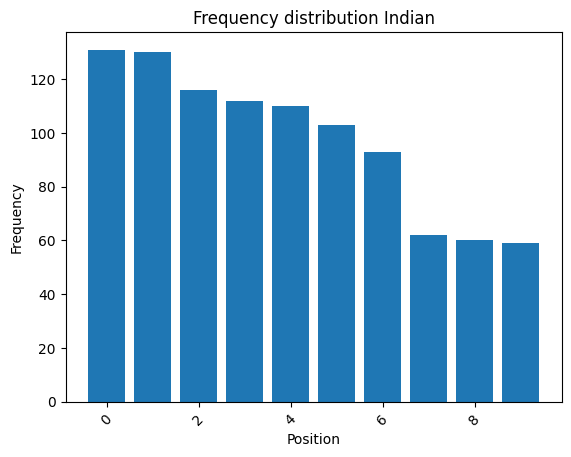

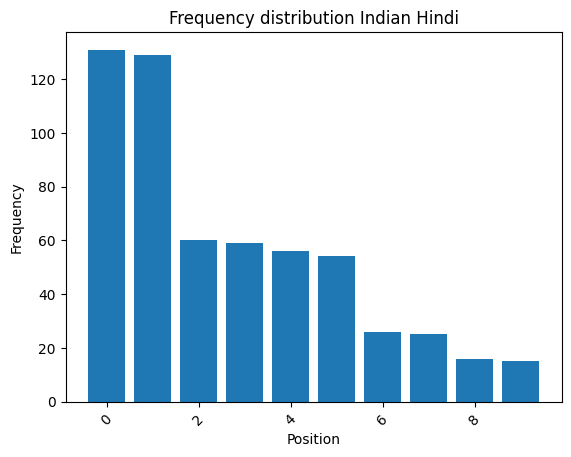

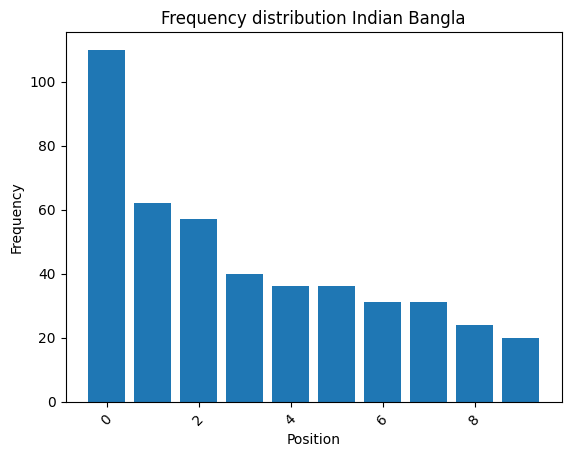

In [77]:
# Step 5 Repeat for the Indian corpus

# 5.1 
commons_indian = common_words(indian.words(), 10)
commons_hindi = common_words(indian.words('hindi.pos'), 10)
commons_bangla = common_words(indian.words('bangla.pos'), 10)
print(commons_indian, commons_hindi, commons_bangla)

# 5.2
extract_insights(indian)
extract_insights(indian, language='hindi')
extract_insights(indian, language='bangla')

# 5.3
tag_freqs_hindi = Counter([p[1] for p in indian.tagged_words('hindi.pos')])
print(tag_freqs_hindi.most_common(10))

# 5.4
plot_frequency_distribution(commons_indian, 'Indian')
plot_frequency_distribution(commons_hindi, 'Indian Hindi')
plot_frequency_distribution(commons_bangla, 'Indian Bangla')

